# Simulation — Ideal Conditions

## Setup

In [ ]:

library(here)


here() starts at C:/Users/pablo/OneDrive/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Fixed-N simulation (continuous data, ML)

Under ideal conditions: continuous multivariate normal data, ML estimator. This should converge with the analytical results from semPower/semTools.

In [ ]:

sim_ideal_fixed <- run_sim(
  nRep     = N_REP,
  n        = 500,
  model    = analyzeModel,
  generate = popModel
)


The RNGkind() was changed from "Mersenne-Twister" to RNGkind("L'Ecuyer-CMRG") in order to enable the multiple streams in the parallel package.
To set a RNG seed using the previous RNGkind(), you can use
    RNGkind("Mersenne-Twister","Inversion","Rejection")
 or 
    set.seed(seed, kind = "Mersenne-Twister")

RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============
           Alpha
Fit Indices       0.1      0.05      0.01     0.001      Mean      SD
      chisq   288.900   297.530   317.032   332.191   251.884  26.449
      aic   28511.303 28571.408 28609.844 28619.269 28310.300 143.642
      bic   28743.106 28803.211 28841.647 28851.072 28542.104 143.642
      rmsea     0.019     0.021     0.024     0.027     0.007   0.008
      cfi       0.993     0.992     0.989     0.987     0.998   0.003
      tli       0.992     0.991     0.987     0.985     0.999   0.005
      srmr      0.033     0.034     0.035     0.036     0.030   0.002
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5_P                     0.918       0.033      0.034
psycho=~Q6_P                     0.813       0.037      0.037
psycho=~Q7_P                     0.940       0.032      0.034
psycho=~Q11_P                  

## Varying-N simulation — Power curve

In [ ]:

sim_ideal_vary <- run_sim(
  nRep     = NULL,
  n        = N_SEQ,
  model    = analyzeModel,
  generate = popModel
)

summary(sim_ideal_vary)


RESULT OBJECT
Model Type
[1] "lavaan"
========= Fit Indices Cutoffs ============

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     N   chisq       aic       bic rmsea   cfi   tli  srmr
1  100 314.747  5839.741  6005.252 0.040 0.968 0.964 0.068
2  325 297.720 18610.406 18811.685 0.031 0.976 0.973 0.056
3  550 280.694 31381.072 31618.118 0.022 0.984 0.983 0.045
4  775 263.668 44151.738 44424.551 0.012 0.992 0.992 0.033
5 1000 246.641 56922.404 57230.984 0.003 1.000 1.002 0.022
========= Parameter Estimates and Standard Errors ============
                      Estimate Average Estimate SD Average SE
psycho=~Q5_P                     0.929       0.043      0.038
psycho=~Q6_P                     0.828       0.050      0.041
psycho=~Q7_P                     0.944       0.039      0.038
psycho=~Q11_P                    0.724       0.037      0.043
psycho=~Q19_P                    0.765       0.048      0.043
psycho=~Q26_P                    0.656       0.046      0.045
physical=~Q3_F                   0.862       0.071      0.060
physical=~Q4_F                   0.840       0.071      0.060
physical=~Q10_F          

## Power for parameters

In [ ]:

# Extract power for each parameter across N values
ideal_power <- getPower(sim_ideal_vary, alpha = ALPHA)

# Find the minimum N for 80% power across all parameters
findPower(ideal_power, "N", POWER_TARGET)


         psycho=~Q5_P          psycho=~Q6_P          psycho=~Q7_P 
                  Inf                   Inf                   Inf 
        psycho=~Q11_P         psycho=~Q19_P         psycho=~Q26_P 
                  Inf                   Inf                   Inf 
       physical=~Q3_F        physical=~Q4_F       physical=~Q10_F 
                  Inf                   Inf                   Inf 
      physical=~Q15_F       physical=~Q16_F       physical=~Q17_F 
                  Inf                   Inf                   Inf 
      physical=~Q18_F         social=~Q20_S         social=~Q21_S 
                  Inf                   Inf                   Inf 
        social=~Q22_S     environment=~Q8_A     environment=~Q9_A 
                  Inf                   Inf                   Inf 
   environment=~Q12_A    environment=~Q13_A    environment=~Q14_A 
                  Inf                   Inf                   Inf 
   environment=~Q23_A    environment=~Q24_A    environment=~Q2

## Power to detect good fit (fit index cutoffs)

In [ ]:

# Power that fit indices fall within rule-of-thumb cutoffs at selected N values
cat("--- Power at N = 300 ---\n")


--- Power at N = 300 ---

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     cfi      tli    rmsea     srmr 
"< 0.48"  "< 0.5" "< 0.48" "< 0.46" 


--- Power at N = 500 ---

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     cfi      tli    rmsea     srmr 
"< 0.48"  "< 0.5" "< 0.48" "< 0.46" 


--- Power at N = 1000 ---

Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique
Warning in rq.fit.br(x, y, tau = tau, ...): Solution may be nonunique

     cfi      tli    rmsea     srmr 
"< 0.46"  "< 0.3" "< 0.46" "< 0.48" 

## Fit index sampling distributions

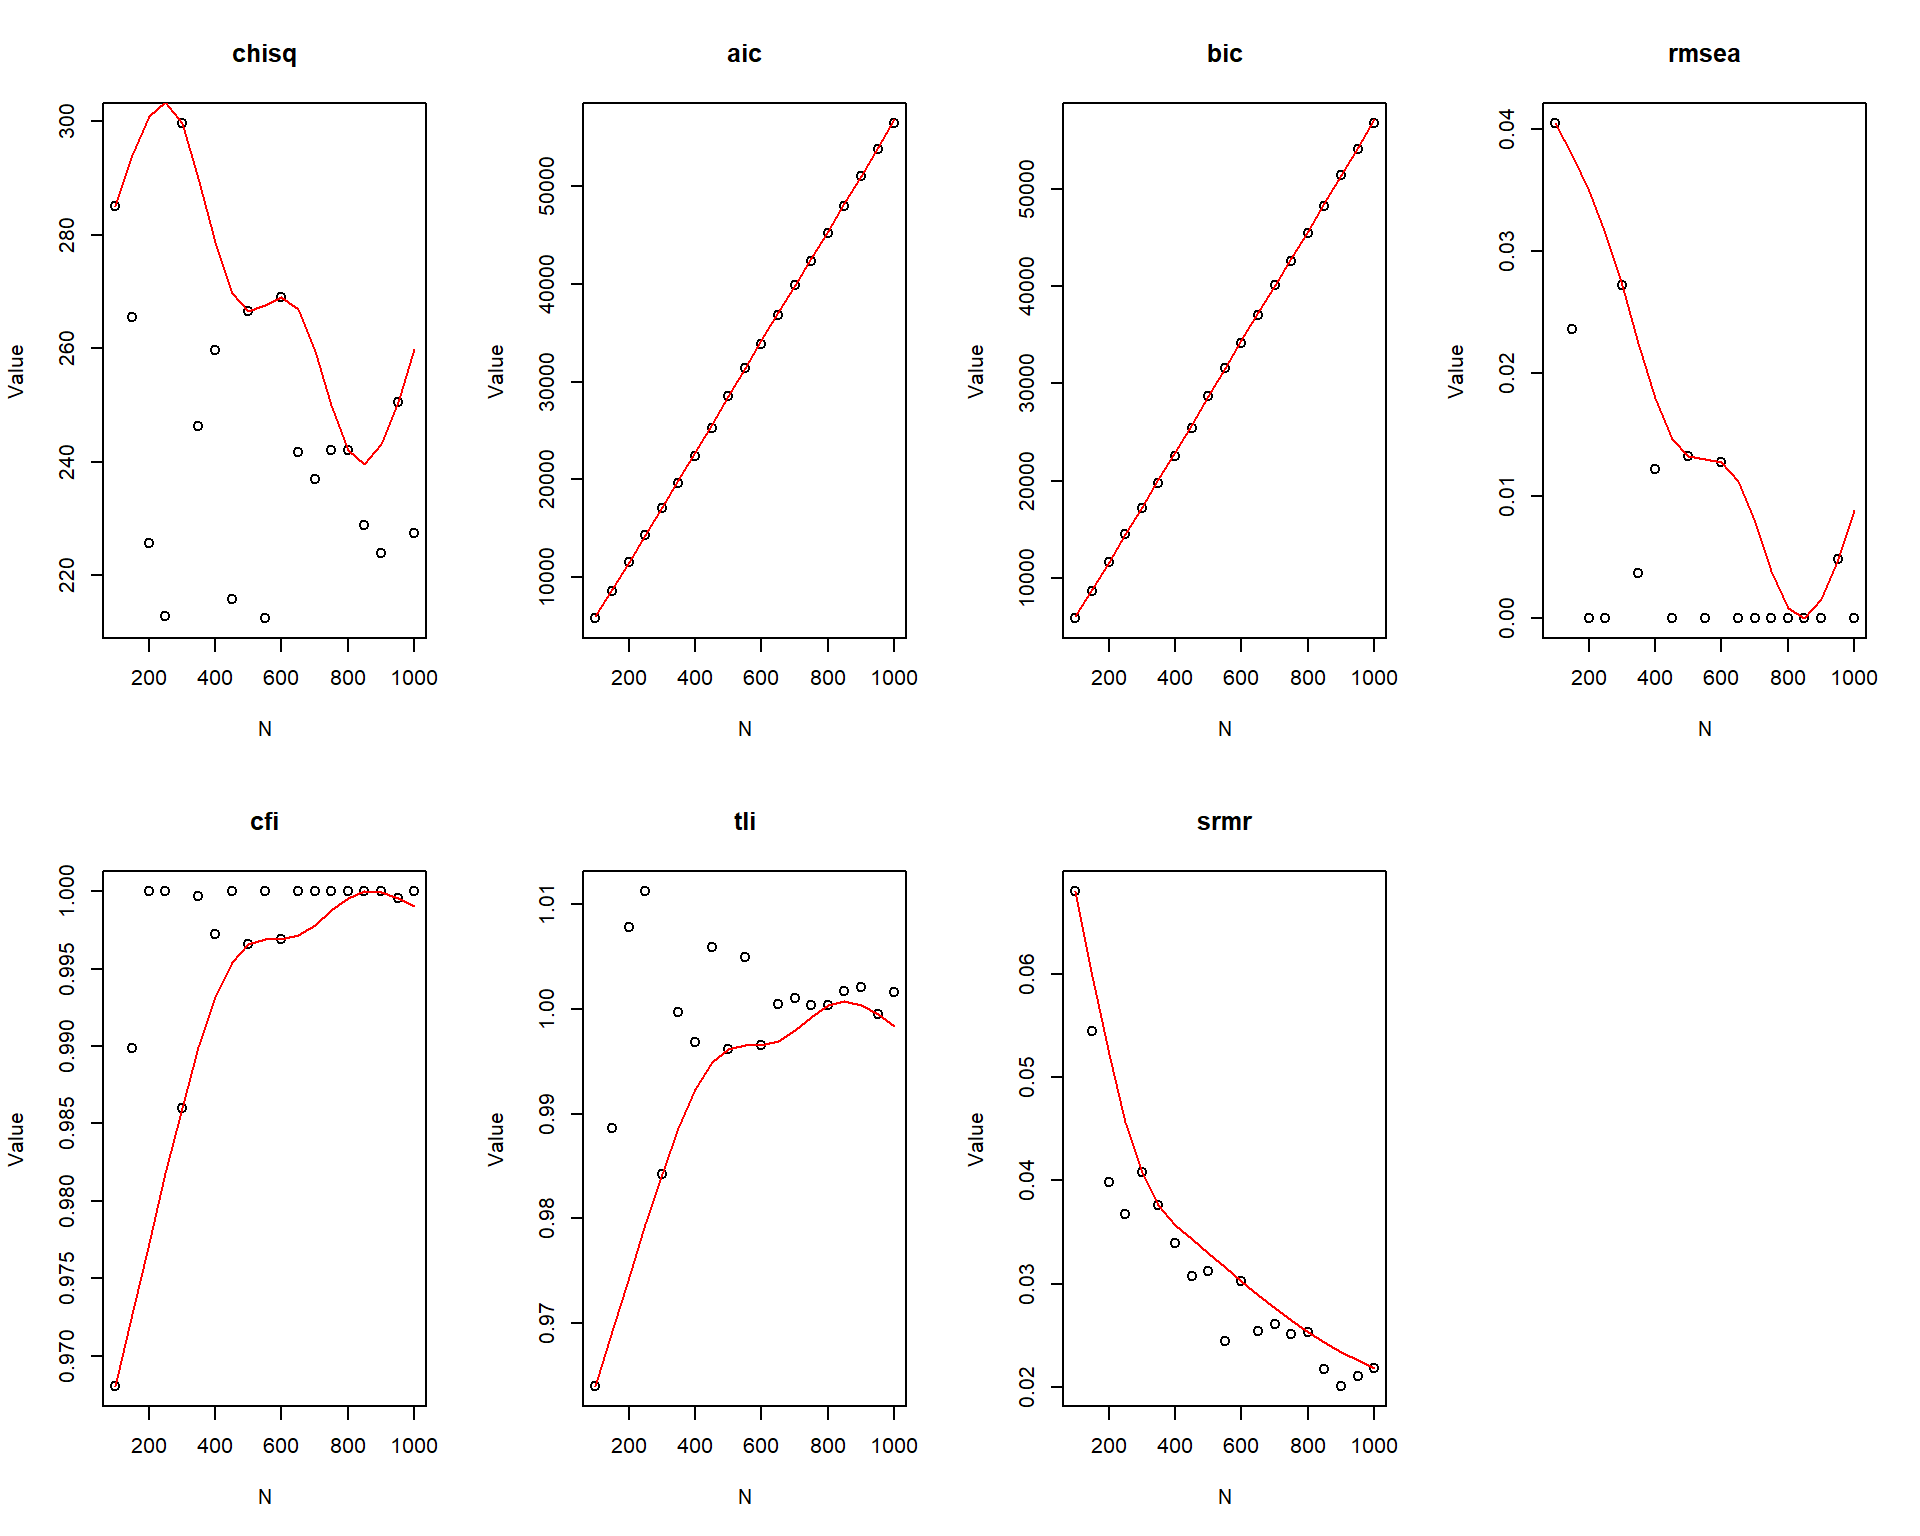

In [ ]:

plotCutoff(sim_ideal_vary, alpha = ALPHA)


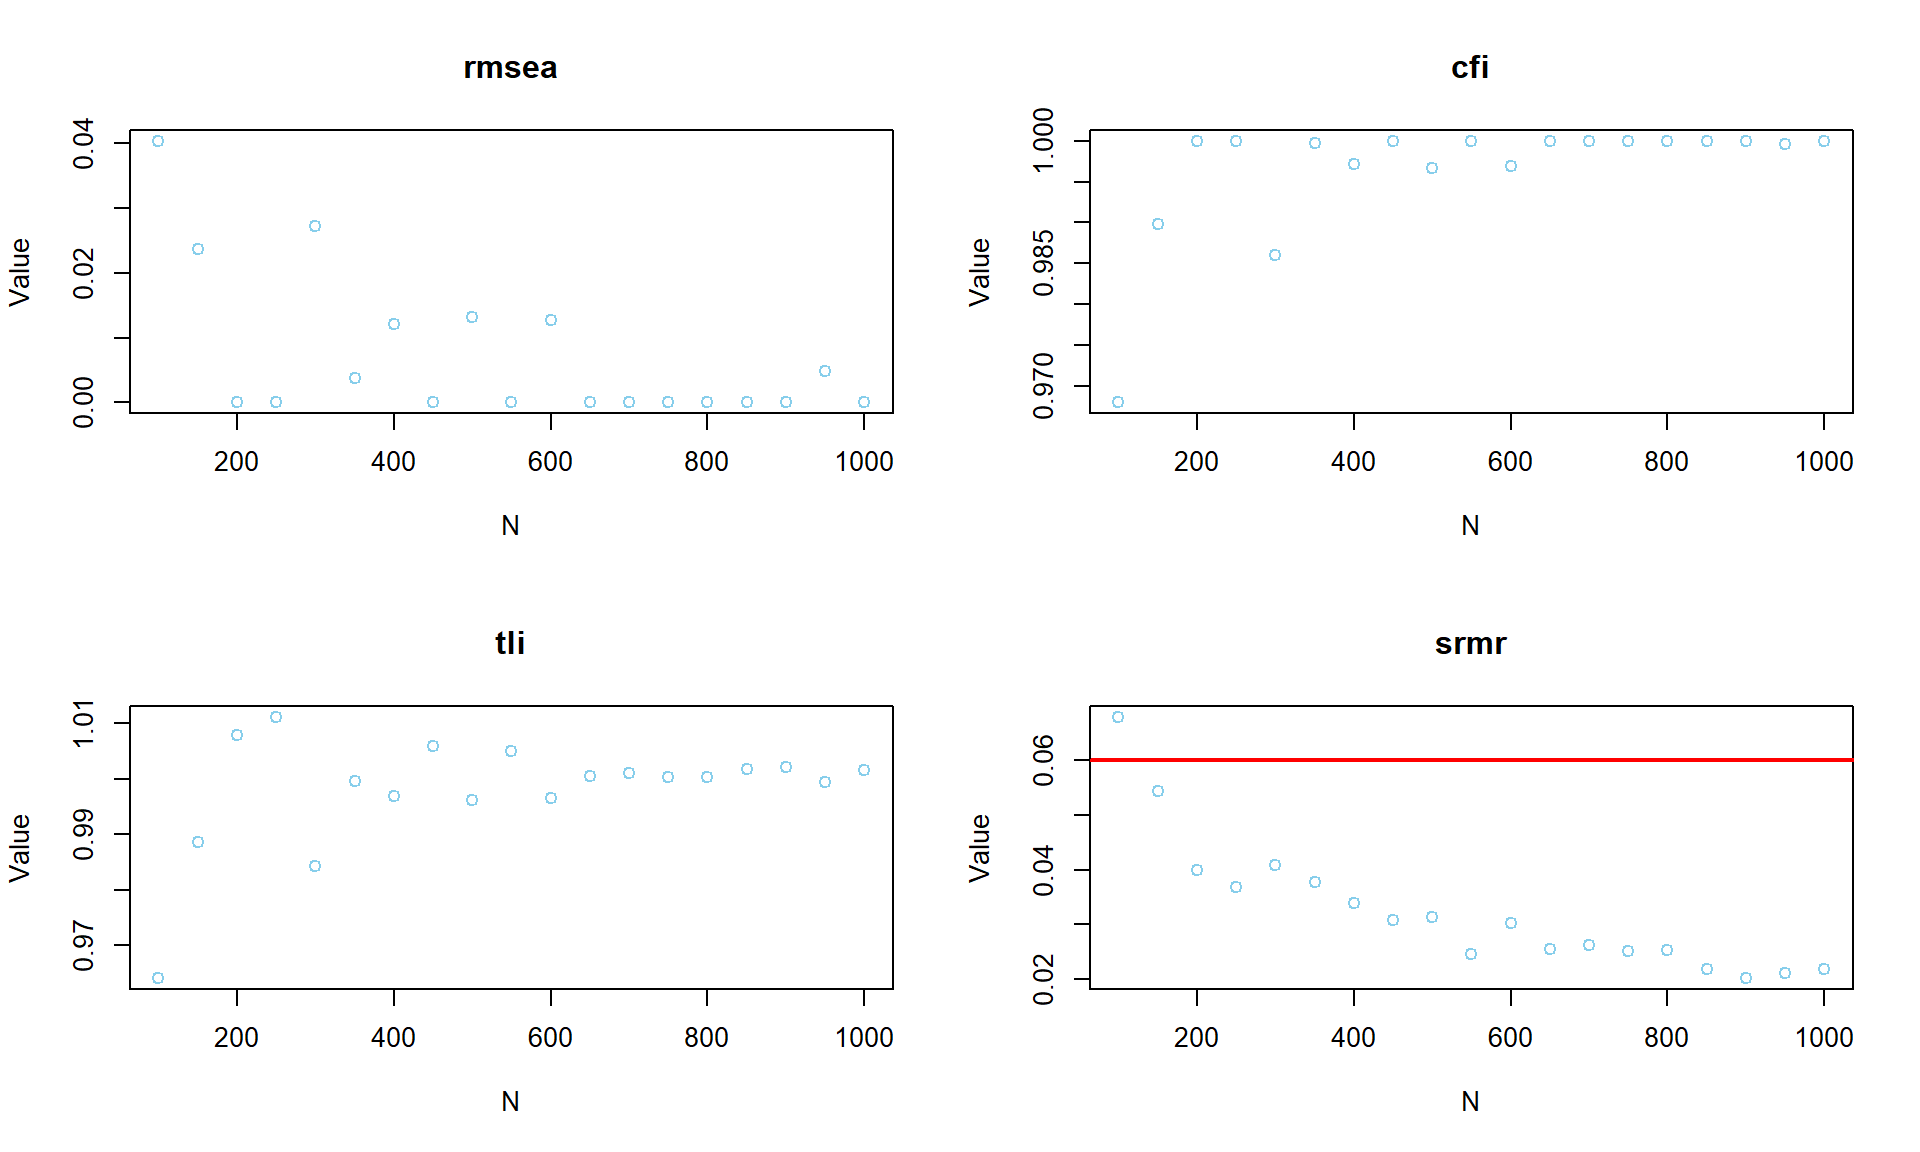

In [ ]:

plotPowerFit(sim_ideal_vary, cutoff = RULE_OF_THUMB, logistic = FALSE)


## Parameter-level summary

In [ ]:

param_summary <- summaryParam(sim_ideal_fixed, detail = TRUE, digits = 3)
kable(param_summary)


  -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                              Estimate   Estimate   Average   Power Std Est Std Est Std Ave   Average   Average   Coverage Rel Bias Std Bias   Rel SE     Not     Not   Average   SD CI
                               Average         SD        SE    (Not              SD      SE     Param      Bias                                  Bias   Cover   Cover  CI Width   Width
                                                              equal                                                                                     Below   Above           
                                                                 0)                                                                                                             
  ------------------------- ---------- ---------- --------- ------- ------- ------- ------- --------- --------- ---------- -------- -------- -------- ------- ------- --------- -------
  psycho=\~Q5_P                  0.918      0.033     0.034       1   0.922   0.009   0.009      0.92    -0.002       0.96   -0.003   -0.074    0.028    0.02    0.02     0.134   0.003

  psycho=\~Q6_P                  0.813      0.037     0.037       1   0.815   0.017   0.016      0.81     0.003       0.94    0.003    0.073    0.005    0.02    0.04     0.145   0.004

  psycho=\~Q7_P                  0.940      0.032     0.034       1   0.940   0.008   0.008      0.94     0.000       0.96    0.000    0.007    0.056    0.02    0.02     0.133   0.004

  psycho=\~Q11_P                 0.729      0.043     0.039       1   0.729   0.024   0.022      0.73    -0.001       0.96   -0.001   -0.025   -0.097    0.02    0.02     0.153   0.004

  psycho=\~Q19_P                 0.751      0.039     0.039       1   0.750   0.022   0.021      0.75     0.001       0.96    0.001    0.020   -0.019    0.02    0.02     0.152   0.004

  psycho=\~Q26_P                 0.631      0.039     0.041       1   0.629   0.028   0.028      0.63     0.001       0.96    0.001    0.023    0.051    0.02    0.02     0.161   0.004

  physical=\~Q3_F                0.834      0.054     0.055       1   0.640   0.029   0.030      0.84    -0.006       0.90   -0.007   -0.112    0.016    0.02    0.08     0.215   0.006

  physical=\~Q4_F                0.835      0.056     0.055       1   0.639   0.027   0.030      0.83     0.005       0.90    0.006    0.089   -0.014    0.02    0.08     0.215   0.006

  physical=\~Q10_F               0.636      0.040     0.042       1   0.634   0.029   0.030      0.63     0.006       0.98    0.010    0.148    0.041    0.02    0.00     0.165   0.005

  physical=\~Q15_F               0.715      0.048     0.041       1   0.711   0.027   0.025      0.71     0.005       0.94    0.007    0.110   -0.149    0.04    0.02     0.160   0.004

  physical=\~Q16_F               0.686      0.037     0.042       1   0.681   0.027   0.027      0.68     0.006       0.98    0.009    0.163    0.125    0.00    0.02     0.163   0.004

  physical=\~Q17_F               0.892      0.035     0.037       1   0.889   0.016   0.015      0.89     0.002       0.98    0.002    0.052    0.042    0.00    0.02     0.145   0.004

  physical=\~Q18_F               0.609      0.047     0.042       1   0.611   0.031   0.031      0.61    -0.001       0.96   -0.002   -0.021   -0.091    0.02    0.02     0.166   0.005

  social=\~Q20_S                 0.935      0.039     0.035       1   0.936   0.013   0.012      0.94    -0.005       0.94   -0.005   -0.121   -0.091    0.00    0.06     0.138   0.003

  social=\~Q21_S                 0.883      0.033     0.036       1   0.887   0.014   0.014      0.89    -0.007       0.96   -0.008   -0.211    0.079    0.04    0.00     0.142   0.003

  social=\~Q22_S                 0.777      0.037     0.038       1   0.781   0.017   0.020      0.78    -0.003       0.98   -0.004   -0.092    0.036    0.00    0.02     0.150   0.004

  environment=\~Q8_A             0.366      0.040     0.045       1   0.368   0.036   0.041      0.37    -0.004       0.98   -0.009   -0.088    0.141    0.00    0.02     0.178   0.005

  environment=\~Q9_A             0.498      0.040     0.044       1   0.495   0.033   0.036      0.49     0.008       0.98    0.016    0.189    0.096    0.02    0.00     0.173   0.006

  environment=\~Q12_A            0.780      0.041     0.039       1   0.784   0.023   0.021      0.79    -0.010       0.96   -0.013   -0.243   -0.052    0.00    0.04     0.151   0.003

  environment=\~Q13_A            0.804      0.035     0.038       1   0.811   0.017   0.019      0.81    -0.006       0.94   -0.007   -0.160    0.076    0.02    0.04     0.149   0.004

  environment=\~Q14_A            0.766      0.038     0.039       1   0.767   0.022   0.022      0.77    -0.004       0.96   -0.006   -0.118    0.038    0.00    0.04     0.153   0.004

  environment=\~Q23_A            0.739      0.035     0.039       1   0.746   0.024   0.023      0.75    -0.011       0.96   -0.014   -0.306    0.130    0.00    0.04     0.154   0.004

  environment=\~Q24_A            0.634      0.044     0.042       1   0.636   0.028   0.029      0.64    -0.006       0.96   -0.009   -0.132   -0.061    0.02    0.02     0.163   0.005

  environment=\~Q25_A            0.720      0.038     0.040       1   0.723   0.025   0.024      0.73    -0.010       0.90   -0.014   -0.275    0.064    0.02    0.08     0.157   0.004

  Q3_F\~\~Q4_F                   0.300      0.044     0.053       1   0.299   0.037   0.044      0.30     0.000       0.96   -0.001   -0.004    0.191    0.02    0.02     0.206   0.010

  Q5_P\~\~Q5_P                   0.148      0.013     0.014       1   0.150   0.017   0.016      0.15    -0.002       0.96   -0.017   -0.185    0.054    0.00    0.04     0.055   0.003

  Q6_P\~\~Q6_P                   0.333      0.021     0.024       1   0.336   0.027   0.027      0.34    -0.007       0.94   -0.021   -0.327    0.103    0.00    0.06     0.093   0.005

  Q7_P\~\~Q7_P                   0.117      0.015     0.013       1   0.117   0.016   0.015      0.12    -0.003       0.94   -0.026   -0.211   -0.100    0.00    0.06     0.052   0.003

  Q11_P\~\~Q11_P                 0.466      0.029     0.031       1   0.468   0.035   0.032      0.47    -0.004       0.96   -0.008   -0.134    0.078    0.00    0.04     0.123   0.007

  Q19_P\~\~Q19_P                 0.438      0.030     0.030       1   0.438   0.033   0.031      0.44    -0.002       0.94   -0.004   -0.065   -0.010    0.04    0.02     0.117   0.007

  Q26_P\~\~Q26_P                 0.608      0.036     0.040       1   0.604   0.035   0.035      0.60     0.008       0.96    0.013    0.207    0.096    0.04    0.00     0.156   0.009

  Q3_F\~\~Q3_F                   0.998      0.066     0.070       1   0.589   0.036   0.038      1.00    -0.002       0.96   -0.002   -0.027    0.050    0.00    0.04     0.273   0.016

  Q4_F\~\~Q4_F                   1.007      0.057     0.070       1   0.591   0.035   0.038      1.00     0.007       0.98    0.007    0.130    0.221    0.02    0.00     0.275   0.014

  Q10_F\~\~Q10_F                 0.600      0.046     0.041       1   0.597   0.037   0.038      0.60     0.000       0.94    0.000    0.001   -0.089    0.02    0.04     0.163   0.011

  Q15_F\~\~Q15_F                 0.496      0.029     0.036       1   0.493   0.038   0.036      0.50    -0.004       1.00   -0.007   -0.129    0.247    0.00    0.00     0.142   0.007

  Q16_F\~\~Q16_F                 0.544      0.042     0.039       1   0.536   0.037   0.037      0.54     0.004       0.92    0.008    0.104   -0.085    0.04    0.04     0.152   0.010

  Q17_F\~\~Q17_F                 0.211      0.025     0.025       1   0.210   0.028   0.027      0.21     0.001       0.96    0.006    0.049   -0.007    0.00    0.04     0.099   0.006

  Q18_F\~\~Q18_F                 0.621      0.041     0.042       1   0.626   0.038   0.038      0.63    -0.009       0.96   -0.014   -0.220    0.038    0.00    0.04     0.166   0.010

  Q20_S\~\~Q20_S                 0.122      0.021     0.022       1   0.123   0.025   0.023      0.12     0.002       0.96    0.016    0.091    0.033    0.04    0.00     0.085   0.004

  Q21_S\~\~Q21_S                 0.210      0.024     0.022       1   0.212   0.025   0.025      0.21     0.000       0.98   -0.002   -0.015   -0.059    0.00    0.02     0.088   0.005

  Q22_S\~\~Q22_S                 0.384      0.027     0.028       1   0.389   0.027   0.031      0.39    -0.006       0.96   -0.016   -0.225    0.045    0.00    0.04     0.111   0.007

  Q8_A\~\~Q8_A                   0.858      0.053     0.055       1   0.864   0.026   0.030      0.86    -0.002       0.96   -0.002   -0.041    0.051    0.00    0.04     0.217   0.013

  Q9_A\~\~Q9_A                   0.760      0.057     0.050       1   0.754   0.033   0.036      0.76     0.000       0.88    0.000    0.002   -0.120    0.04    0.08     0.196   0.014

  Q12_A\~\~Q12_A                 0.381      0.029     0.030       1   0.385   0.036   0.032      0.38     0.001       0.96    0.002    0.026    0.026    0.00    0.04     0.116   0.007

  Q13_A\~\~Q13_A                 0.337      0.029     0.027       1   0.342   0.028   0.030      0.34    -0.003       0.88   -0.010   -0.115   -0.048    0.04    0.08     0.108   0.007

  Q14_A\~\~Q14_A                 0.409      0.031     0.031       1   0.412   0.034   0.033      0.41    -0.001       0.92   -0.001   -0.016   -0.003    0.02    0.06     0.122   0.007

  Q23_A\~\~Q23_A                 0.436      0.037     0.032       1   0.444   0.035   0.034      0.44    -0.004       0.92   -0.009   -0.103   -0.138    0.00    0.08     0.127   0.009

  Q24_A\~\~Q24_A                 0.591      0.036     0.041       1   0.595   0.036   0.037      0.59     0.001       0.96    0.001    0.024    0.140    0.02    0.02     0.159   0.009

  Q25_A\~\~Q25_A                 0.472      0.036     0.034       1   0.477   0.035   0.035      0.47     0.002       0.96    0.004    0.049   -0.055    0.00    0.04     0.134   0.009

  psycho\~\~physical             0.305      0.051     0.044       1   0.305   0.051   0.044      0.30     0.005       0.90    0.017    0.103   -0.121    0.06    0.04     0.174   0.006

  psycho\~\~social               0.297      0.047     0.044       1   0.297   0.047   0.044      0.30    -0.003       0.96   -0.009   -0.058   -0.079    0.02    0.02     0.171   0.005

  psycho\~\~environment          0.307      0.048     0.044       1   0.307   0.048   0.044      0.30     0.007       0.94    0.024    0.154   -0.072    0.04    0.02     0.173   0.005

  physical\~\~social             0.301      0.043     0.045       1   0.301   0.043   0.045      0.30     0.001       0.96    0.003    0.023    0.054    0.04    0.00     0.177   0.005

  physical\~\~environment        0.311      0.052     0.046       1   0.311   0.052   0.046      0.30     0.011       0.94    0.036    0.209   -0.121    0.06    0.00     0.179   0.006

  social\~\~environment          0.292      0.047     0.045       1   0.292   0.047   0.045      0.30    -0.008       0.94   -0.026   -0.165   -0.028    0.02    0.04     0.177   0.005
  -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


## Convergence: Analytical vs. Simulation

In [ ]:

# Note: fill in analytical_n after running 03_analytical_power.qmd
# For now, use placeholder that will be replaced by the embed output
convergence_table <- data.frame(
  Approach = c("semPower a priori (RMSEA ≥ .05)",
               "semTools a priori (RMSEA ≥ .05)",
               "simsem (parameter power, max N)",
               "simsem (fit power at SRMR < .06)"),
  `N for 80% Power` = c(
    "See @sec-apriori",
    "See @sec-apriori",
    "From findPower() above",
    "From getPowerFit() above"
  ),
  Notes = c(
    "Model-free, RMSEA-based",
    "Same underlying math",
    "Continuous/ML, population model",
    "Continuous/ML, population model"
  ),
  check.names = FALSE
)

kable(convergence_table, align = "lll")


  ------------------------------------------------------------------------
  Approach                   N for 80% Power     Notes
  -------------------------- ------------------- -------------------------
  semPower a priori (RMSEA ≥ See @sec-apriori    Model-free, RMSEA-based
  .05)                                           

  semTools a priori (RMSEA ≥ See @sec-apriori    Same underlying math
  .05)                                           

  simsem (parameter power,   From findPower()    Continuous/ML, population
  max N)                     above               model

  simsem (fit power at SRMR  From getPowerFit()  Continuous/ML, population
  \< .06)                    above               model
  ------------------------------------------------------------------------
